In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold,RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import VotingRegressor
import pickle


In [24]:
df_all=pd.read_csv('umap_all_data.csv')
df_umap=pd.read_csv('umap_target_data.csv')

In [25]:
#отделяем признаки от целевой переменной и делаем ее логарифмирование
targets = ['IC50, mM', 'CC50, mM', 'SI']
all_features = [col for col in df_all.columns if col not in targets]
X_all = df_all[all_features].copy()
all_features2 = [col for col in df_umap.columns if col not in targets]
X_umap = df_umap[all_features2].copy()
y_a = df_all['IC50, mM']
y_u = df_umap['IC50, mM']

In [26]:
#делим выборку на обучающую и валидационную
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(X_all, y_a, test_size=0.2, random_state=42)
X_u_train, X_u_test, y_u_train, y_u_test = train_test_split(X_umap, y_u, test_size=0.2, random_state=42)


In [27]:
scaler_robust = RobustScaler()
X_a_train_r = pd.DataFrame(scaler_robust.fit_transform(X_a_train), columns=X_a_train.columns, index=X_a_train.index)
X_a_test_r = pd.DataFrame(scaler_robust.transform(X_a_test), columns=X_a_test.columns, index=X_a_test.index)

In [28]:
#т.к. целевая переменная имеет скошенное распределние (медиана сильно отличается от среднего), делаем логарифмирование
y_train_log = np.log1p(y_a_train)
y_test_log = np.log1p(y_a_test)

In [30]:
y_u_train_log = np.log1p(y_u_train)
y_u_test_log = np.log1p(y_u_test)

In [39]:
#выбираем нелинейные модели для обучения
#определяем cv для кроссвалидации
models = {'Ridge':{'model': Ridge(random_state=42),
        'params': {'alpha': [0.01, 0.1, 1, 10, 50, 100]}},
          'Lasso': {'model': Lasso(random_state=42, max_iter=10000),
        'params': {'alpha': [0.001, 0.01, 0.1, 1, 10]}},
          'Random Forest': {'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {'n_estimators': [200, 230, 300],
                   'max_depth': [10, 15,18],
                   'min_samples_split': [3, 4, 5],
                   'min_samples_leaf': [2, 3, 4]}},
          'Gradient Boosting': {'model': GradientBoostingRegressor(random_state=42),
        'params': {'n_estimators': [220, 250, 300],
                   'learning_rate': [0.02, 0.04, 0.06],
                   'max_depth': [3, 4, 5],
                   'subsample': [0.6, 0.8]}},
          'XGBoost': {'model': XGBRegressor(random_state=42, verbosity=0),
        'params': {'n_estimators': [220, 250, 300],
            'max_depth': [3, 4, 5],
            'learning_rate': [0.01, 0.03, 0.05]}},
          'LightGBM': {'model': LGBMRegressor(random_state=42, verbose=-1),
        'params': {'n_estimators': [100, 120, 140],
            'num_leaves': [7, 9, 11],
            'learning_rate': [0.05, 0.1]}},
          'SVM': {'model': SVR(),
        'params': {'C': [10, 20, 25],
                   'gamma': ['auto', 0.1],
                   'epsilon': [0.3, 0.5]}},
          'KNN': {'model': KNeighborsRegressor(),
        'params': {'n_neighbors': [12, 15, 18, 25],
                    'weights': ['uniform', 'distance'],
                   'metric': ['euclidean', 'manhattan']}}}


In [40]:
#обучаем модели и сохраняем лучшие результаты
results = []
best_models = {}
print('Модели на всех признаках')
for name, config in models.items():
  grid = GridSearchCV(config['model'], config['params'],
        cv=5, scoring='r2', n_jobs=-1, verbose=0)
  grid.fit(X_a_train_r, y_train_log)

  best_model = grid.best_estimator_
  best_models[name] = best_model

  y_pred_log = best_model.predict(X_a_test_r)
  y_pred = np.expm1(y_pred_log)
  y_true = np.expm1(y_test_log)
  r2 = r2_score(y_true, y_pred)
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))

  results.append({'Model': name,
        'Best Params': str(grid.best_params_),
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'CV R2': grid.best_score_})
  print(f'\n{name}')
  print(f'Лучшие параметры: {grid.best_params_}')
  print(f'R² (исходная шкала): {r2:.4f}')
  print(f'MAE: {mae:.4f}')
  print(f'RMSE: {rmse:.4f}')
  print(f'CV R²: {grid.best_score_:.4f}')

Модели на всех признаках

Ridge
Лучшие параметры: {'alpha': 100}
R² (исходная шкала): -0.0913
MAE: 242.0292
RMSE: 549.0375
CV R²: -0.1007

Lasso
Лучшие параметры: {'alpha': 10}
R² (исходная шкала): -0.1757
MAE: 256.4730
RMSE: 569.8866
CV R²: -0.0041

Random Forest
Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 230}
R² (исходная шкала): 0.2534
MAE: 205.6206
RMSE: 454.1266
CV R²: 0.4180

Gradient Boosting
Лучшие параметры: {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 250, 'subsample': 0.8}
R² (исходная шкала): 0.2988
MAE: 200.7490
RMSE: 440.1158
CV R²: 0.4172

XGBoost
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}
R² (исходная шкала): 0.2669
MAE: 201.9440
RMSE: 449.9908
CV R²: 0.4042

LightGBM
Лучшие параметры: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 11}
R² (исходная шкала): 0.2734
MAE: 200.7039
RMSE: 447.9890
CV R²: 0.4022

SVM
Лучшие параметры: {'C': 10, 'epsilon': 0.5, 'ga

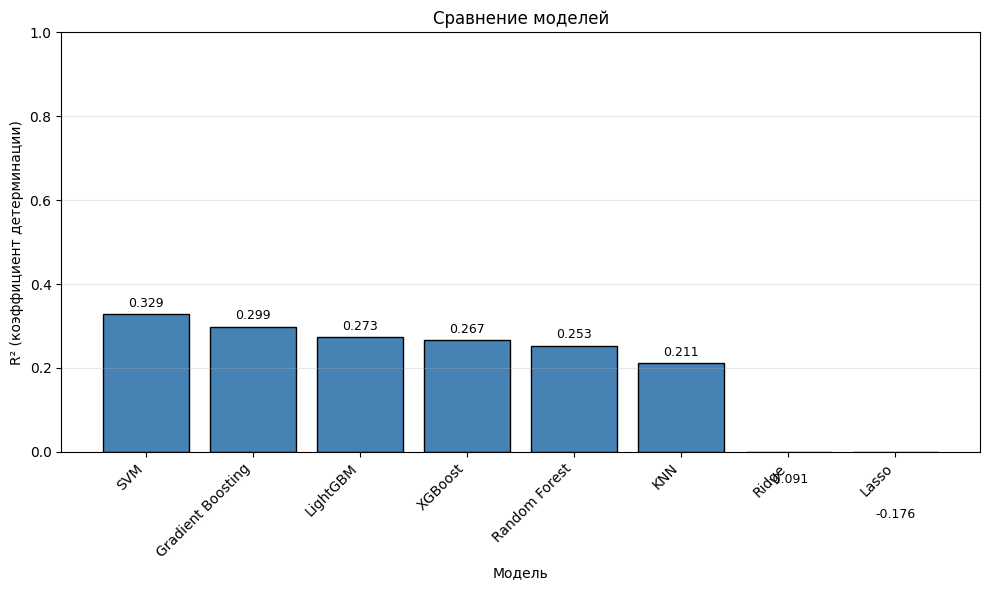

In [41]:
results = pd.DataFrame(results)
results = results.sort_values('R2', ascending=False)
plt.figure(figsize=(10, 6))
bars = plt.bar(results['Model'], results['R2'], color='steelblue', edgecolor='black')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)
plt.xlabel('Модель')
plt.ylabel('R² (коэффициент детерминации)')
plt.title('Сравнение моделей')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
#проверяем модели только на UMAP признаках
results_umap = []
best_models = {}
print('Модели на UMAP признаках')
for name, config in models.items():
  grid = GridSearchCV(config['model'], config['params'],
        cv=5, scoring='r2', n_jobs=-1, verbose=0)
  grid.fit(X_u_train, y_u_train_log)

  best_model = grid.best_estimator_
  best_models[name] = best_model

  y_pred_log = best_model.predict(X_u_test)
  y_pred = np.expm1(y_pred_log)
  y_true = np.expm1(y_u_test_log)
  r2 = r2_score(y_true, y_pred)
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))

  results_umap.append({'Model': name,
        'Best Params': str(grid.best_params_),
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'CV R2': grid.best_score_})
  print(f'\n{name}')
  print(f'Лучшие параметры: {grid.best_params_}')
  print(f'R² (исходная шкала): {r2:.4f}')
  print(f'MAE: {mae:.4f}')
  print(f'RMSE: {rmse:.4f}')
  print(f'CV R²: {grid.best_score_:.4f}')

Модели на UMAP признаках

Ridge
Лучшие параметры: {'alpha': 10}
R² (исходная шкала): -0.1526
MAE: 251.0934
RMSE: 564.2528
CV R²: 0.0602

Lasso
Лучшие параметры: {'alpha': 0.001}
R² (исходная шкала): -0.1523
MAE: 250.9875
RMSE: 564.1812
CV R²: 0.0600

Random Forest
Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 300}
R² (исходная шкала): 0.0612
MAE: 220.7274
RMSE: 509.2226
CV R²: 0.2776

Gradient Boosting
Лучшие параметры: {'learning_rate': 0.02, 'max_depth': 5, 'n_estimators': 220, 'subsample': 0.8}
R² (исходная шкала): 0.0266
MAE: 228.2567
RMSE: 518.5208
CV R²: 0.2686

XGBoost
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}
R² (исходная шкала): 0.0122
MAE: 228.3130
RMSE: 522.3631
CV R²: 0.2575

LightGBM
Лучшие параметры: {'learning_rate': 0.1, 'n_estimators': 120, 'num_leaves': 7}
R² (исходная шкала): 0.0601
MAE: 224.5901
RMSE: 509.5217
CV R²: 0.2716

SVM
Лучшие параметры: {'C': 10, 'epsilon': 0.3, 'gamm

Лучшие параметры: {'C': 10, 'epsilon': 0.5, 'gamma': 0.1}
R² (исходная шкала): 0.3292

In [67]:
#оставляем лучшие модели и подбираем параметры более точно
param_dist = {'C': [1, 3, 5, 7, 10, 15, 20, 30, 50],
    'epsilon': [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0],
    'gamma': ['scale', 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3]}
svr = SVR()
search_svr = RandomizedSearchCV(svr, param_dist, n_iter=50, cv=9, scoring='r2', n_jobs=-1, random_state=42)
search_svr.fit(X_a_train_r, y_train_log)
best_svr = search_svr.best_estimator_
print(f'Лучшие параметры SVR: {search_svr.best_params_}')
y_pred_svr_log = best_svr.predict(X_a_test_r)
y_pred_svr = np.expm1(y_pred_svr_log)
y_true = np.expm1(y_test_log)
r2_svr = r2_score(y_true, y_pred_svr)
mae_svr = mean_absolute_error(y_true, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_true, y_pred_svr))
print('SVR')
print(f'Тест R²: {r2_svr:.4f}')
print(f'MAE: {mae_svr:.2f}')
print(f'RMSE: {rmse_svr:.2f}')
print(f'CV R²: {search_svr.best_score_:.4f}')

Лучшие параметры SVR: {'gamma': 0.2, 'epsilon': 0.8, 'C': 3}
SVR
Тест R²: 0.2115
MAE: 210.28
RMSE: 466.70
CV R²: 0.3764


In [68]:
#оставляем модель из первого поиска парметров
best_svr = SVR(C=10, epsilon=0.5, gamma=0.1)
best_svr.fit(X_a_train_r, y_train_log)
y_pred_log = best_svr.predict(X_a_test_r)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test_log)
r2_svr = r2_score(y_true, y_pred)
mae_svr = mean_absolute_error(y_true, y_pred)
rmse_svr = np.sqrt(mean_squared_error(y_true, y_pred))
print('SVR')
print(f'Тест R²: {r2_svr:.4f}')
print(f'MAE: {mae_svr:.2f}')
print(f'RMSE: {rmse_svr:.2f}')

SVR
Тест R²: 0.3292
MAE: 197.57
RMSE: 430.44


In [74]:
gb_params = {'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.02, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]}
gb = GradientBoostingRegressor(random_state=42)
random_search_gb = RandomizedSearchCV(
    gb, gb_params, n_iter=40, cv=5, scoring='r2',
    n_jobs=-1, random_state=42, verbose=0)
random_search_gb.fit(X_a_train_r, y_train_log)
best_gb = random_search_gb.best_estimator_
print(f'Лучшие параметры GB: {random_search_gb.best_params_}')
y_pred_gb_log = best_gb.predict(X_a_test_r)
y_pred_gb = np.expm1(y_pred_gb_log)
r2_gb = r2_score(y_true, y_pred_gb)
mae_gb = mean_absolute_error(y_true, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_true, y_pred_gb))
print('Gradient boosting')
print(f'Тест R²: {r2_gb:.4f}')
print(f'MAE: {mae_gb:.2f}')
print(f'RMSE: {rmse_gb:.2f}')


Лучшие параметры GB: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 4, 'learning_rate': 0.02}
Gradient boosting
Тест R²: 0.3412
MAE: 198.53
RMSE: 426.58


In [75]:
#составляем ансамбль из полученных моделей
weights = [r2_svr, r2_gb]
weights = [max(0, r2_svr) + 0.1, max(0, r2_gb) + 0.1]
voting_reg = VotingRegressor(estimators=[('svr', best_svr), ('gb', best_gb)], weights=weights)
voting_reg.fit(X_a_train_r, y_train_log)
y_pred_ens_log = voting_reg.predict(X_a_test_r)
y_pred_ens = np.expm1(y_pred_ens_log)
r2_ens = r2_score(y_true, y_pred_ens)
mae_ens = mean_absolute_error(y_true, y_pred_ens)
rmse_ens = np.sqrt(mean_squared_error(y_true, y_pred_ens))
print('Ансамбль')
print(f'Тест R²: {r2_ens:.4f}')
print(f'MAE: {mae_ens:.2f}')
print(f'RMSE: {rmse_ens:.2f}')

Ансамбль
Тест R²: 0.3342
MAE: 197.18
RMSE: 428.84


In [76]:
#сохраняем полученную модель
with open('best_reg_ic50.pkl', 'wb') as f:
    pickle.dump(best_gb, f)
with open('scaler_reg_ic50.pkl', 'wb') as f:
    pickle.dump(scaler_robust, f)

print('Модель и компоненты сохранены в сессионное хранилище')

Модель и компоненты сохранены в сессионное хранилище


In [77]:
#проверяем загрузку
with open('best_reg_ic50.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('scaler_reg_ic50.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

print('Модель и компоненты загружены')

Модель и компоненты загружены
